In [27]:
import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import SAGEConv, GraphConv, GraphSAGE
import torch
import networkx as nx 
from torch.utils.data import Dataset, DataLoader
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'sim'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from GraphDatAll import GraphDataset
torch.manual_seed(42)

In [28]:
class GraphEncoderWithResidual(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphEncoderWithResidual, self).__init__()
        # self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow='target_to_source', root_weight=False)
        # self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow='target_to_source', root_weight=False)
        # self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow='target_to_source', root_weight=False)
        self.conv1 = SAGEConv(in_channels, hidden_channels*4, flow='source_to_target', root_weight=False)
        self.conv2 = SAGEConv(hidden_channels*4, hidden_channels*2, flow='source_to_target', root_weight=False)
        self.conv3 = SAGEConv(hidden_channels*2, hidden_channels, flow='source_to_target', root_weight=False)
        self.lin1 = nn.Linear(hidden_channels, int(hidden_channels/2))
        self.lin2 = nn.Linear(int(hidden_channels/2), out_channels)
        # Linear transformation to match dimensions for residual connection
        self.shortcut = nn.Linear(in_channels, out_channels)
        # self.sm = nn.Softmax(dim=1)

    def forward(self, x, edge_index):
        identity = x
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        x = F.dropout(F.relu(self.lin1(x)), p=0.2)
        x = self.lin2(x)
        # Applying shortcut and adding it to the output of conv3
        identity = self.shortcut(identity)
        x += identity  # Element-wise addition
        # x = self.sm(x)
        return x

In [29]:
def round_function(x, d):
    new = []
    for r in x:
        new.append(np.round(r,decimals=d))
    # pdb.set_trace()
    return tuple(new)

In [30]:
# Assuming a loss function appropriate for node feature reconstruction, e.g., MSE for continuous features
def loss_function(reconstructed_x, original_x):
    # weights = torch.tensor([  2204787.0/14022   ,2204787.0/35079,  2204787.0/780448 ,2204787.0/1375238], dtype=torch.float)
    # total = 1.0#2204689.0
    # arr = [1410221,  794468] 
    # arr = [1.0, 1.0]
    # weights = torch.tensor([total/a for a in arr], dtype = torch.float)
    
    # weights = weights/torch.sum(weights)
    # return F.cross_entropy(reconstructed_x, original_x, weight=weights, label_smoothing=0.2)
    # return F.cross_entropy(reconstructed_x, original_x, label_smoothing=0.4)
    return F.cross_entropy(reconstructed_x, original_x)#, weight=weights)
    # return F.cross_entropy(reconstructed_x, original_x)#/scale#, label_smoothing=0.4)   

In [31]:
def train(model, dataloader, optimizer, device):#, timeclasses):
    
    model.train()
    total_loss = 0
    embeddings = []
    origs = []
    qs = []
    agents = []
    printlosses = []
    for feat, edge, _, _, q, nA, ts in dataloader:
        optimizer.zero_grad()
        features = feat.squeeze_(0).to(device)
        edges = edge.squeeze_(0).to(device)
        embed = model(features, edges)
        
        qs.append(q)
        agents.append(nA)

        # time_classes = times.squeeze_(0).to(device)
        # succ_classes = succ.squeeze_(0).to(device)
        # time_succ_class = torch.cat([time_classes, succ_classes], axis=-1)
        # pdb.set_trace()
        loss = loss_function(embed, ts.squeeze_(0).to(device)) #cosine_loss(data[1][0].to(device), embed)
        origs.append(ts.detach())
        # loss = cosine_loss(embed, classes) 
        # loss = focal_loss(embed, data[2][0].to(device)) #cosine_loss(data[1][0].to(device), embed)
        loss.backward()
        optimizer.step()
        total_loss += loss.detach().item()
        printlosses.append(loss.detach().item())
        if len(printlosses)%1000 == 0:
            printlosses = printlosses[-1000:]
            print(np.sum(printlosses)/1000.0)
        embeddings.append(embed.detach())
        # print(total_loss)/10.0
    return total_loss / len(dataloader), embeddings, origs, qs, agents

In [32]:
folder_graph = './'
device = "cpu"
# fname = 'small_graphs.pth'
# files = os.listdir(folder_graph)
# files = [file for file in files if file.endswith('.pickle')]
# files = ['alledges', 'allsucc', 'alltime', 'edgesList', 'nodeIDs']
hC = 20
inC = 40
outchannels = 4

In [33]:


# dataset = GraphDataset(folder_graph, files)
# dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)
actuals = []
final_loss = []
embeddings = []
fg = './finished_with_labels/'
files = os.listdir(fg)
files = [file for file in files if file.endswith('.pickle')]
dataset = GraphDataset(fg, files)#, meta)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=8)

# dataloader=
# dataloader = [torch.tensor(times_, dtype=torch.long).to(device), torch.tensor(nodesList, dtype=torch.float).to(device), torch.tensor(edges, dtype=torch.long).t().to(device)]
model = GraphEncoderWithResidual(in_channels=inC, hidden_channels=hC, out_channels=outchannels).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.1)
# scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
losses = []
embeds = []
acts = []
# timeclasses = torch.tensor(times_, dtype=torch.long).to(device)

In [34]:


for epoch in range(1, 5):  # Number of epochs
    loss, _, _, _, _ = train(model, dataloader, optimizer, device)#, timeClasses)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
    # scheduler.step(loss)
# epoch_loss = loss / len(dataloader)
# embeddings.append(embeds)
# final_loss.append(losses)
# actuals.append(acts)
# model.eval()
# # Assuming encoder and decoder are your model's components
# encoder_state_dict = model.state_dict()
# # decoder_state_dict = model.decoder.state_dict()
# # Save the state dictionaries
# torch.save(encoder_state_dict, str(hC) +'ALLSucc_encoder_state_dict'+str(outchannels)+'.pth')
# torch.save(decoder_state_dict, './CDC/decoder_state_dict'+str(outchannels)+'.pth')
        # print(np.shape(embed), np.shape(data[2][0]), np.shape(data[0][0]), np.shape(data[1][0]))


1.261635019293928
1.1445729019848077
1.1186665302162895
1.3140948553610745
Epoch 1, Loss: 1.2078
1.2165543583500253
1.2215473382809878
1.256195034236828
1.2789679448635722
Epoch 2, Loss: 1.2386
1.2123288627141664
1.272947020078059
1.3741932514160011
1.2855481776086344
Epoch 3, Loss: 1.2831
1.1576507591010796
1.2827256501771074
1.2375336068213663
1.3390243770166526
Epoch 4, Loss: 1.2534


In [35]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(1, 5):  # Number of epochs
    loss, _, _, _, _ = train(model, dataloader, optimizer, device)#, timeClasses)
    # embeds.append(embed)
    # acts.append(orig)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
# model.eval()
# encoder_state_dict = model.state_dict()
# torch.save(encoder_state_dict, str(hC) +'ALLSucc_encoder_state_dict'+str(outchannels)+'.pth')


0.7735445879768568
0.7359258926024195
0.6865595286859607
0.6774941765832336
Epoch 1, Loss: 0.7203
0.6976510009663179
0.708679640969931
0.6986344961738796
0.6602913977786957
Epoch 2, Loss: 0.6950
0.6942624318042071
0.6718429798318539
0.681454309322813
0.7010457796421251
Epoch 3, Loss: 0.6835
0.6506934788373765
0.712575204942259
0.6777632669979358
0.6962567503128084
Epoch 4, Loss: 0.6852


In [36]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
embeds = []
acts = []
qarr = []
agarr = []
for epoch in range(1, 3):  # Number of epochs
    loss, embed, orig, qs, agents = train(model, dataloader, optimizer, device)#, timeClasses)
    embeds.append(embed)
    acts.append(orig)
    agarr.append(agents)
    qarr.append(qs)
    print(f'Epoch {epoch}, Loss: {loss:.4f}')
    # losses.append(loss)
model.eval()
encoder_state_dict = model.state_dict()
torch.save(encoder_state_dict, str(hC) +'ALLSucc_encoder_state_dict'+str(outchannels)+'.pth')

fl = open(str(hC) + 'succall_classresults_3_5.pickle', 'wb')
pickle.dump(embeds, fl)
fl.close()

fl = open(str(hC) + 'succall_classactuals_3_5.pickle', 'wb')
pickle.dump(acts, fl)
fl.close()

# fl = open(str(hC) + 'succall_classquals_3_5.pickle', 'wb')
# pickle.dump(qarr, fl)
# fl.close()

# fl = open(str(hC) + 'succall_classagents_3_5.pickle', 'wb')
# pickle.dump(agarr, fl)
# fl.close()


0.6577257746057585
0.6237472402541898
0.6591407179865055
0.6208671719133854
Epoch 1, Loss: 0.6410


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x10a8450d0>>
Traceback (most recent call last):
  File "/Users/puneet/Library/Python/3.9/lib/python/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


: 

In [ ]:

# fil2 = open('MULTIPLEalltime.pickle', 'rb')
# times = pickle.load(fil2)
# fil2.close()

# fil2 = open('allsucc.pickle', 'rb')
# successes = pickle.load(fil2)
# fil2.close()

# fil2 = open('edgeList.pickle', 'rb')
# edges = pickle.load(fil2)
# fil2.close()

# fil2 = open('nodeIDs.pickle', 'rb')
# nodes = pickle.load(fil2)
# fil2.close()

# meanTimes = dict()
# for n in times:
#     meanTimes[n] = np.mean(times[n])
# TIME_LIMIT =  400

# def round_function(x, d):
#     new = []
#     for r in x:
#         new.append(np.round(r,decimals=d))
#     # pdb.set_trace()
#     return tuple(new)

# def get_class(a):
#     if a > TIME_LIMIT:
#         return 0
#         retVal = torch.tensor(0, dtype=torch.long)
#         return retVal
#     else:
#         return 1
#         retVal = torch.tensor(1, dtype=torch.long)
#         return retVal
    # arr = []
    # if a > TIME_LIMIT:
    #     arr.append(0)
    # else:
    #     arr.append(1)

    # try:
    #     retVal = torch.tensor(arr, dtype=torch.long)
    #     return retVal
    # except:
    #     pdb.set_trace()
    # edges
# timeClasses = dict()
# for n in meanTimes:
#     timeClasses[n] = get_class(meanTimes[n])

# times_ = []
# for t in timeClasses.values():
#     times_.append(t)


# nodesList = []
# for n in nodes:
#     nodesList.append(n)


In [ ]:
# optimizer = optim.Adam(model.parameters(), lr=0.0001)

# for epoch in range(1, 5):  # Number of epochs
#     loss, embed, orig = train(model, dataloader, optimizer, device)
#     # embeds.append(embed)
#     # acts.append(orig)
#     print(f'Epoch {epoch}, Loss: {loss:.4f}')
#     # losses.append(loss)
# model.eval()
# encoder_state_dict = model.state_dict()
# torch.save(encoder_state_dict, './ALLTime_encoder_state_dict'+str(outchannels)+'.pth')

In [ ]:
# GAE = GraphEncoderWithResidual(inC, hC, outchannels)
# import pickle
# import numpy as np
# import torch


# from collections import defaultdict 

# encoder_dict = torch.load('./ALLTime_encoder_state_dict2.pth')


In [ ]:

# GAE = GraphEncoderWithResidual(inC, hC, outchannels)
# GAE.load_state_dict(encoder_dict)
# emb = []
# arrtosave = []

In [ ]:
# print(np.shape(torch.tensor([nodesList[0]], dtype=torch.float)), np.shape(torch.tensor([[],[]], dtype=torch.long)))
# GAE(torch.tensor([nodesList[0]], dtype=torch.float), torch.tensor([[],[]], dtype=torch.long))


In [ ]:

# # for i in arr1: 
# GAE.eval()
# emb = []
# for ii in nodesList: 
#     # break
# # GAE(torch.tensor([ast.literal_eval(i)], dtype=torch.float), torch.empty((2,0), dtype=torch.int64).detach().tolist()[0])
#     try:
#         # pdb.set_trace()
#         emb.append(GAE(torch.tensor([ii], dtype=torch.float), torch.tensor([[],[]], dtype=torch.long)).detach().tolist()[0])
#         # arrtosave.append(i) 
#     except Exception as e:
#         print(e)
#         print(np.shape(ii))

In [ ]:
# times_
# times_check = []
# for t in times_:
#     times_check.append(t.tolist())

In [ ]:
# import numpy as np
# from scipy.special import expit, logit
# emb
# newembs = []
# for e in emb:
#     newembs.append(expit(e))

# newembs
# emb

In [ ]:
# print(np.shape(times_check), np.shape(emb))

# y_true_indices = times_check#np.argmax(times_check, axis=1)
# y_pred_indices = np.argmax(emb, axis=1)
# # print(np.argmax(emb, axis=1)[0:10])
# # print(np.argmax(arrclass, axis=1)[0:10])
# loss, embed, orig, qs, agents = train(model, dataloader, optimizer, device)#, timeClasses)
# embeds.append(embed)
# acts.append(orig)
# agarr.append(agents)
# qarr.append(qs)
# print(np.shape(embeds[0]))
# print(embeds)
# print(np.shape(acts))
y_true_indices = []
y_pred_indices = []
outs = []
counter = 0
for ee, oo, qq in zip(embeds, acts, qarr):
    counter +=1
    # print(np.shape(ee), np.shape(oo))
    for id, (e, o, q) in enumerate(zip(ee, oo, qq)):
        outs+=e.tolist()
        y_true_indices+=list(o)
        y_pred_indices+=np.argmax(e, axis=1)
        # break
    # break
# print(y_true_indices, y_pred_indices)


In [ ]:
# out = np.array(outs)
# # print(np.shape(out[:,0]))
# cols = []
# for i in y_true_indices:
#     if i == 0:
#         cols.append([1,0,0])
#     else:
#         cols.append([0,1,0])


In [ ]:
# print(np.shape(y_true_indices), np.shape(y_pred_indices))
# # colors = ['r','g']

# plt.scatter(out[:,0], out[:,1], c=cols, s=2)


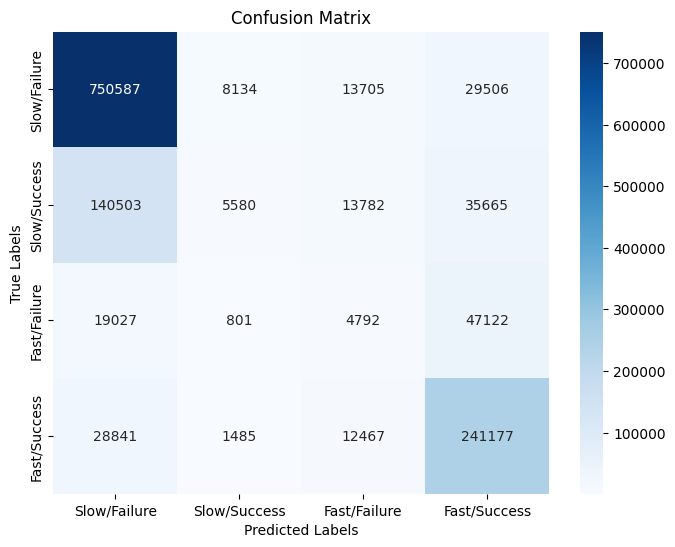

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

    # def get_succtimeclass(self, s, t):
    #     if s < SUCC_LIMIT and t > TIME_LIMIT:
    #         return 0 # slow fail
    #     elif s >= SUCC_LIMIT and t > TIME_LIMIT:
    #         return 1 # slow success
    #     elif s < SUCC_LIMIT and t <= TIME_LIMIT:
    #         return 2 # fast fail
    #     elif s >= SUCC_LIMIT and t <= TIME_LIMIT:
    #         return 3 # fast success
    #     else:
cm = confusion_matrix(y_true_indices, y_pred_indices)
# ConfusionMatrixDisplay(cm).plot()
CLIST =  ["Slow/Failure", "Slow/Success", "Fast/Failure", "Fast/Success"]

# CLIST =  ["SLOW", "FAST"]
# CLIST= ["BEST SITE", "OTHER SITE"]
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()
# 

In [ ]:
# from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score

In [ ]:
# print('roc auc score: ', roc_auc_score(y_true_indices, y_pred_indices))
# print('precision score: ', precision_score(y_true_indices, y_pred_indices))
# print('recall score: ', recall_score(y_true_indices, y_pred_indices))
# print('f1 score: ', f1_score(y_true_indices, y_pred_indices))
# print('accuracy score: ', accuracy_score(y_true_indices, y_pred_indices))


10:

roc auc score:  0.7847262434011781
precision score:  0.7394655295706757
recall score:  0.7593559617058312
f1 score:  0.7492787655149278
accuracy score:  0.7890321560834613

5: 

roc auc score:  0.7807121435124047
precision score:  0.7352067868504772
recall score:  0.7542428198433421
f1 score:  0.7446031575555795
accuracy score:  0.7852045885647186

In [ ]:


# print(np.sum([1 for y in y_true_indices if y == 1]))
# total = np.sum(cm, axis=1)
# print(total, np.sum(total))
# print(cm)
# 0: 14022, 1: 35079, 2: 780448 1375238

In [2]:
# import torch
# import statistics
# arr = []
# for a in meta:
#     arr.append(statistics.mean(meta[a]))

# times_ = []
# for t in timeClasses.values():
#     times_.append(t)
# # print(n)
# import matplotlib.pyplot as plt
# x=plt.hist(times_)
# plt.xlim([0,200])


# import shutil
# import os
# import numpy as np
# import pandas as pd
# from ast import literal_eval
# from collections import defaultdict
# def other():
#     folder = '../../graphsage_results/CDC/multiple_agent_env_results/'
#     files = os.listdir(folder)
#     files = [file for file in files if file.endswith('.csv') and file.startswith('1')]
#     files = np.sort(files)
#     # data_files = []
#     metadata_file = folder + 'metadata.csv'
#     # folder_graph = './graphs/RS/fast_multiple_graphs/'
#     # new_metadata_file = folder_graph + 'metadata.csv'
#     # graph_metaFile = 'graphMetadata.csv'
#     # meta_arr = []
#     metadata = pd.read_csv(metadata_file) 
#     metadata.site_qualities=metadata.site_qualities.apply(literal_eval)
#     metadata.site_positions=metadata.site_positions.apply(literal_eval)
#     metadata.site_positions=metadata.site_positions.apply(lambda x: tuple([tuple(a) for a in x]))
#     metadata.site_qualities=metadata.site_qualities.apply(lambda x: tuple(x))
#     df = metadata.groupby(by=['site_qualities', 'site_positions', 'num_agents'], as_index=False).agg(lambda x: x.tolist())
#     Gtime = defaultdict(list)
#     Gsucc = defaultdict(list)
#     Gedge = defaultdict(defaultdict)
    
#     for some_id, entry in enumerate(df.iterrows()):
#         # copy files
#         for file in entry[1].iloc[3]:
#             shutil.copyfile(folder+file, '../../oneGraphFiles/'+file)
#         break

# other()

import torch
from torch import nn
import torch_geometric
from torch_geometric.nn import GATConv, SAGEConv, GraphConv, GraphSAGE, GCNConv, GATv2Conv
import torch
import networkx as nx 
from torch.utils.data import Dataset
import pickle
import pdb 
import numpy as np
from torch_geometric.data import Data
import networkx as nx
import numpy as np
import pandas as pd 
import pickle
import pdb
from torch_geometric.loader import DataLoader
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.utils import to_dense_adj, subgraph, k_hop_subgraph
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.join(os.path.dirname(sys.path[0]),'tools'))
from sklearn.neighbors import kneighbors_graph
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.data import Data
# from newGraphDat import GraphDataset
from GraphDatAll import GraphDataset
from sklearn.manifold import TSNE
import matplotlib as mpl
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# from graphDat import GraphDataset
# from ClassGraphDat import GraphDataset

torch.manual_seed(42)
 

class GATNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, p):
        super(GATNet, self).__init__()
        # Define the first GAT convolution layer
        self.conv1 = GATConv(in_channels, hidden_channels*4, heads=8)#, dropout=0.3)
        # Define the second GAT convolution layer
        self.conv2 = GATConv(hidden_channels*4 * 8, hidden_channels*2, heads=8, concat=True)#, dropout=0.3)
        # Define the third GAT convolution layer
        self.conv3 = GATConv(hidden_channels*2 * 8, hidden_channels, heads=1, concat=True)#, dropout=0.3)
        # Define a linear layer to refine the outputs to the desired size
        self.linear = nn.Linear(hidden_channels, out_channels)
        self.shortcut = nn.Linear(in_channels, out_channels)
        self.p = p

    def forward(self, x, edge_index):
        init = x
        # x, edge_index = data.x, data.edge_index
        # Apply dropout to the input features and pass through the first GAT layer
        x = F.dropout(x, p=self.p, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        # Pass through the second GAT layer
        x = F.dropout(x, p=self.p, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        # Pass through the third GAT layer
        x = F.dropout(x, p=self.p, training=self.training)
        x = F.elu(self.conv3(x, edge_index))
        # Apply the linear layer
        x = self.linear(x)
        x = x + self.shortcut(init)
        return x
    
def cosine_loss(adj, emb, ew):
    # pdb.set_trace()
    norms = torch.norm(emb, p=2, dim=1, keepdim=True)
    normalized_embeddings = emb / norms.clamp(min=1e-4)
    cosine_similarity_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())
    target_adjacency = torch.zeros_like(cosine_similarity_matrix)
    normalized_weights = ew / torch.norm(ew, p=2, keepdim=True)
    target_adjacency[adj[0], adj[1]] = normalized_weights
    # Directly using logits; no need to apply sigmoid.
    return F.binary_cross_entropy_with_logits(cosine_similarity_matrix, target_adjacency)


def train(model, data_loader, optimizer, device):
    model.train()
    total_loss = 0
    embeddings = []
    # origs = []
    qs = []
    agents = []
    # printlosses = []
    for feat, edge, edge_weight, _, _, _, _, _ in dataloader:
        optimizer.zero_grad()
        # pdb.set_trace()
        # print(np.shape(feat), np.shape(edges))
        # print('in main: ', np.shape(feat), np.shape(edges))
        features = feat.squeeze_(0).to(device)
        # globalInfo = glob.squeeze_(0).to(device)
        edges = edge.squeeze_(0).to(device)
        ew = edge_weight.squeeze_(0).to(device)
        embed = model(features, edges)
        loss = cosine_loss(edges, embed, ew)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        embeddings.append(embed.detach())
        # print(total_loss)
    return total_loss / len(data_loader), embeddings#, origs

# Copy code
def validate(model, data_loader, device):
    model.eval()
    total_loss = 0
    counter = 0 
    validation_embeddings = []
    # validation_classes = []
    qs = []
    agents = []
    origs = []
    with torch.no_grad():
        for feat, edge, ew, _, _, q, nA, ts in data_loader:
            counter += 1
            features = feat.squeeze_(0).to(device)
            edges = edge.squeeze_(0).to(device)
            embed = model(features, torch.empty((2,1), dtype=torch.int64))
            validation_embeddings.append(embed.detach())
            qs.append(q)
            agents.append(nA)
            origs.append(ts.detach())
            # if counter < 5:
            #     print(embed)
            loss = cosine_loss(edges, embed, ew)
            total_loss += loss.item()
    return total_loss / len(data_loader), validation_embeddings, origs, qs, agents



def get_color(node, quals, na):
    red = node_to_color_red(node, quals, na)
    green = node_to_color_green(node, quals, na)
    black = node_to_color_black(node)
    if red is True:
        return 'r'
    elif green is True:
        return 'g'
    elif black is True:
        return 'k'
    else:
        return 'b'

    

def get_complete_poses(a):
    arr = [[MAX_DIST]*2]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = list(a[i])
    # pdb.set_trace()
    return arr

def get_complete_quals(a):
    arr = [0]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = a[i]
    # pdb.set_trace()
    return arr

def get_complete_global(a):
    arr = [0]*4
    for i in range(0,len(a)):
        # pdb.set_trace()
        arr[i] = a[i]
    # pdb.set_trace()
    return arr

def node_to_color_black(node):
    if node[3] == 0.0:
        return True
    else:
        return False

def node_to_color_green(node, quals, nA):
    # pdb.set_trace()
    # nA = np.sum([1 for _ in node[0::4]])
    dancers = [(1, q) for a, q in zip(node[0::4], node[3::4]) if a == 0.0]
    qs = [0]*4
    # pdb.set_trace()
    for d in dancers:
        ii = quals.index(d[1])
        qs[ii] += 1

    if np.max(qs) > COMMIT_THRESHOLD*nA:
        id = np.argmax(qs)
        if quals[id] == np.max(quals):
            return True
        else:
            return False
    else:
        return False
    
def node_to_color_red(node, quals, nA):
    # pdb.set_trace()
    # nA = np.sum([1 for _ in node[0::4]])
    dancers = [(1, q) for a, q in zip(node[0::4], node[3::4]) if a == 0.0]
    qs = [0]*4
    # pdb.set_trace()
    for d in dancers:
        ii = quals.index(d[1])
        qs[ii] += 1

    if np.max(qs) > COMMIT_THRESHOLD*nA:
        id = np.argmax(qs)
        if quals[id] != np.max(quals):
            return True
        else:
            return False
    else:
        return False


if __name__ == '__main__':
    folder_graph = './finished_some_train/'
    device = "cpu"

    inC = 40

    nW = 8

    # fname = 'small_graphs.pth'
    folder_graph_train = './finished_some_test/'
    files_train = os.listdir(folder_graph_train)
    files_train = [file for file in files_train if file.endswith('.pickle')]

    files = os.listdir(folder_graph)
    files_to_val = [file for file in files if file.endswith('.pickle') and (file not in files_train) and file.startswith('(')] #and (file not in files_test)
    print(len(files_train), len(files_to_val))
    dataset = GraphDataset(folder_graph, files_to_val)
    dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=nW)

    dataset_test = GraphDataset(folder_graph, files_to_val)
    dataloader_test = DataLoader(dataset_test, batch_size=1, shuffle=True, num_workers=nW)

    for hC in [8]:#[8, 16]: #[8, 64]:#[8, 16, 32, 64]:#[8, 16, 32, 64]:
        for drops in [0.6]: #[0.4, 0.6]: #[0.2, 0.4, 0.6, 0.8]:#[0.2, 0.4, 0.6, 0.8]:
            for lrate in [0.01]:#[0.001, 0.05, 0.005, 0.01]: #[0.01, 0.05, 0.001, 0.005]:
                for decays in [0.01]:#[0.01, 0.0]: #[0]: #[5e-5, 0]:#[5e-4, 5e-5, 5e-3, 0.0]:
                    

                    print('hidden count: ', hC, 'drops: ', drops, 'lr: ', lrate, 'decays: ', decays)

                    actuals = []
                    final_loss = []
                    embeddings = []
                    outchannels = 4

                    model = GATNet(inC, hC, outchannels, drops).to(device)
                    optimizer = optim.AdamW(model.parameters(), lr=lrate, weight_decay=decays)
                    # scheduler = ReduceLROnPlateau(optimizer, 'min', factor=0.1, patience=3, verbose=True)
                    # losses = []
                    embeds = []
                    # torch.autograd.set_detect_anomaly(True)
                    # acts = []
                    for epoch in range(2, 3):  # Number of epochs
                        # loss, embed, orig = train(model, dataloader, optimizer, device)
                        loss, _ = train(model, dataloader, optimizer, device)
                        # embeds.append(embed)
                        # acts.append(orig)
                        print(f'Epoch {epoch}, Loss: {loss:.4f}')
                        if epoch % 2 == 0:
                            # In your main training loop:
                            # total_loss / len(data_loader), validation_embeddings, origs, qs, agents
                            validation_loss, ve, TSve, qs, ags  = validate(model, dataloader_test, device)
                            print(f'Validation Loss: {validation_loss:.4f}')

                    model.eval()
                    encoder_state_dict = model.state_dict()
                    optim_state_dict = optimizer.state_dict()
                    

5679 147
hidden count:  8 drops:  0.6 lr:  0.01 decays:  0.01
Epoch 2, Loss: 0.7857
Validation Loss: 1.2112


Text(0.5, 1.0, 'Confusion Matrix for 3-level GAT embedding')

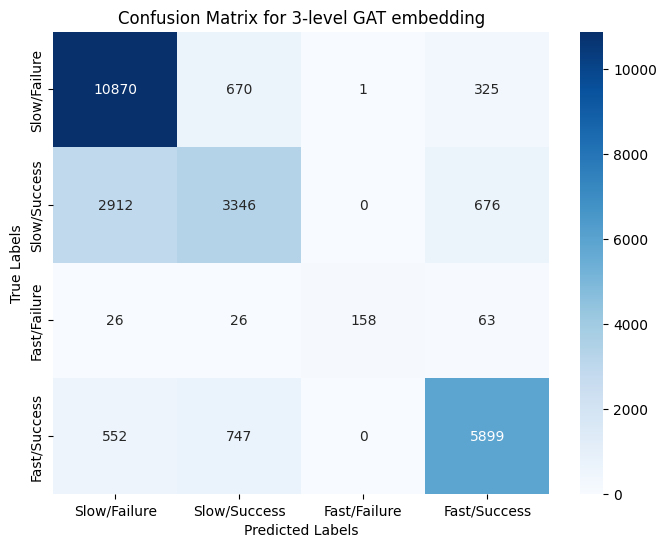

In [4]:
CLIST =  ["Slow/Failure", "Slow/Success", "Fast/Failure", "Fast/Success"]
X = []
y = []
for vv, tsts in zip(ve, TSve):
    # pdb.set_trace()
    for v in vv:
        X.append(v.tolist())
    y+=tsts[0].tolist()  

# X = []
est = GradientBoostingClassifier(n_estimators=200, max_depth=3) # n_estimators is the number of trees and max_depth is the maximum depth of any individual tree.
est.fit(X, y)

y_pred = est.predict(X)
cm = confusion_matrix(y, y_pred)#, labels = bin_dict.values())
# CLIST =  bin_dict.values()

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLIST, yticklabels=CLIST)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix for 3-level GAT embedding')

In [8]:
folder_graph = './finished_some_train/'
files = os.listdir(folder_graph)
folder_params = './parameter_test_files/'
import shutil
for file in files[:-1]:
    if np.random.random() > 0.5:
        shutil.copy(folder_graph + file, folder_params + file)

In [10]:
folder_graph = './finished_some_train/'
device = "cpu"

inC = 40

nW = 8

# fname = 'small_graphs.pth'
folder_graph_train = './finished_some_test/'
files_train = os.listdir(folder_graph_train)
files_train = [file for file in files_train if file.endswith('.pickle')]

files = os.listdir(folder_graph)
files_to_val = [file for file in files if file.endswith('.pickle') and (file not in files_train) and file.startswith('(')] #and (file not in files_test)


In [11]:
# def new_func():
#     return files_to_val

# len(new_func())

147

In [15]:
folder_graph = './finished_some_all/'
# files = os.listdir(folder_graph)
folder_val = './validation_set/'


import shutil
for file in files_to_val[:-1]:
    print(file)
    # if np.random.random() > 0.5:
    shutil.copy(folder_graph + file, folder_val + file)

(0.064, 0.479, 0.983)((200.0, 0.0), (-100.0, 173.205), (-100.0, -173.205))5_1710456707381719.csv_noAgentPos_single_sim.pickle
(0.101, 0.673)((100.0, 0.0), (-100.0, 0.0))10_1710456704051108.csv_noAgentPos_single_sim.pickle
(0.399, 0.133, 0.933, 0.249)((200.0, 0.0), (0.0, 200.0), (-200.0, 0.0), (-0.0, -200.0))5_1710456709348890.csv_noAgentPos_single_sim.pickle
(0.774, 0.072)((100.0, 0.0), (-100.0, 0.0))10_1710456704709307.csv_noAgentPos_single_sim.pickle
(0.89, 0.176, 0.333)((150.0, 0.0), (-75.0, 129.904), (-75.0, -129.904))5_1710456707434486.csv_noAgentPos_single_sim.pickle
(0.775, 0.197, 0.152, 0.044)((150.0, 0.0), (0.0, 150.0), (-150.0, 0.0), (-0.0, -150.0))5_1710456709218232.csv_noAgentPos_single_sim.pickle
(0.101, 0.673)((200.0, 0.0), (-200.0, 0.0))10_1710456704087143.csv_noAgentPos_single_sim.pickle
(0.356, 0.939)((100.0, 0.0), (-100.0, 0.0))10_1710456704780609.csv_noAgentPos_single_sim.pickle
(0.356, 0.939)((150.0, 0.0), (-150.0, 0.0))10_1710456704959198.csv_noAgentPos_single_sim.

In [1]:
# np.random.random()
import os 
import shutil
import numpy as np
folder_graph = './25pGraphs/'
files = os.listdir(folder_graph)
folder_params = './25pGraphs_val/'
import shutil
for file in files[:-1]:
    if np.random.random() > 0.9:
        shutil.copy(folder_graph + file, folder_params + file)